# **Laboratorio 8: Ejercicios**


Ejercicio 1:
Genere tres señales:

* 5 Hz
* 20 Hz
* 80 Hz

Diseñe un filtro pasa banda que permita únicamente:
15 Hz a 30 Hz
Presente: Señal temporal y FFT antes/después

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import firwin, lfilter

# Parametros de señal
fs = 1000
T = 1
t = np.linspace(0, T, int(fs*T), endpoint=False)
# Señales senos
f_5hz = 5
f_20hz = 20
f_80hz = 80
signal_5hz = np.sin(2 * np.pi * f_5hz * t)
signal_20hz = np.sin(2 * np.pi * f_20hz * t)
signal_80hz = np.sin(2 * np.pi * f_80hz * t)

# Señal combinada
composite_signal = signal_5hz + signal_20hz + signal_80hz

# Parametros filtros
N = 101
f1 = 15
f2 = 30

### Señal Original (Antes de Filtrar)

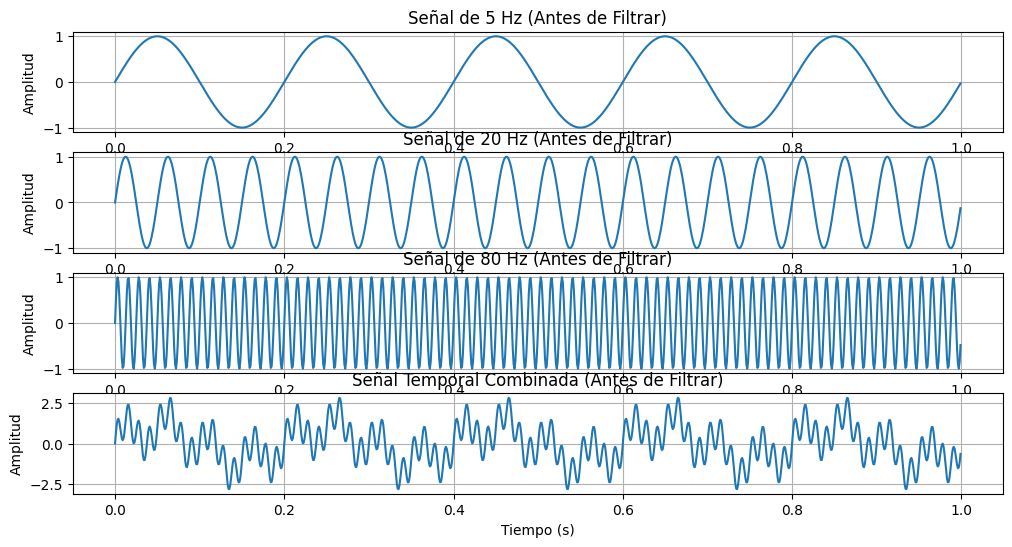

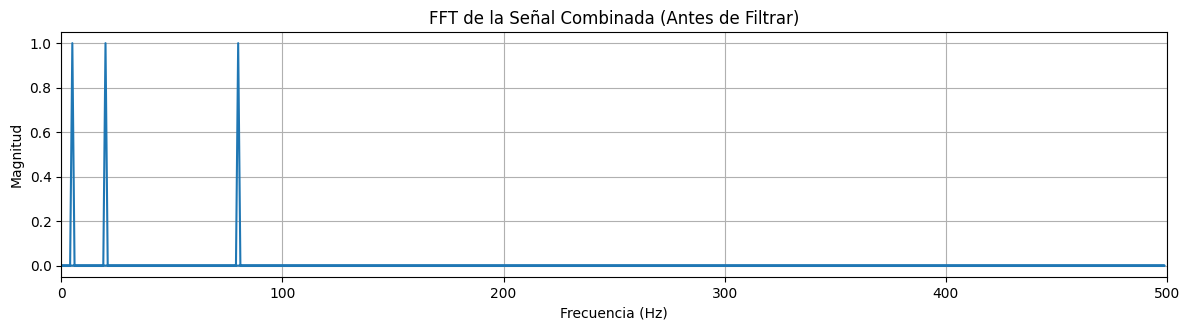

In [5]:
# Ploteo de señales
plt.figure(figsize=(12, 6))
plt.subplot(4, 1, 1)
plt.plot(t, signal_5hz)
plt.title('Señal de 5 Hz (Antes de Filtrar)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)

plt.subplot(4, 1, 2)
plt.plot(t, signal_20hz)
plt.title('Señal de 20 Hz (Antes de Filtrar)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)

plt.subplot(4, 1, 3)
plt.plot(t, signal_80hz)
plt.title('Señal de 80 Hz (Antes de Filtrar)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)

plt.subplot(4, 1, 4)
plt.plot(t, composite_signal)
plt.title('Señal Temporal Combinada (Antes de Filtrar)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)


# FFT y plot de fft
N_fft = len(composite_signal)
yf = np.fft.fft(composite_signal)
xf = np.fft.fftfreq(N_fft, 1/fs)

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 2)
plt.plot(xf, 2/N_fft * np.abs(yf))
plt.title('FFT de la Señal Combinada (Antes de Filtrar)')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Magnitud')
plt.xlim(0, fs/2)
plt.grid(True)
plt.tight_layout()
plt.show()



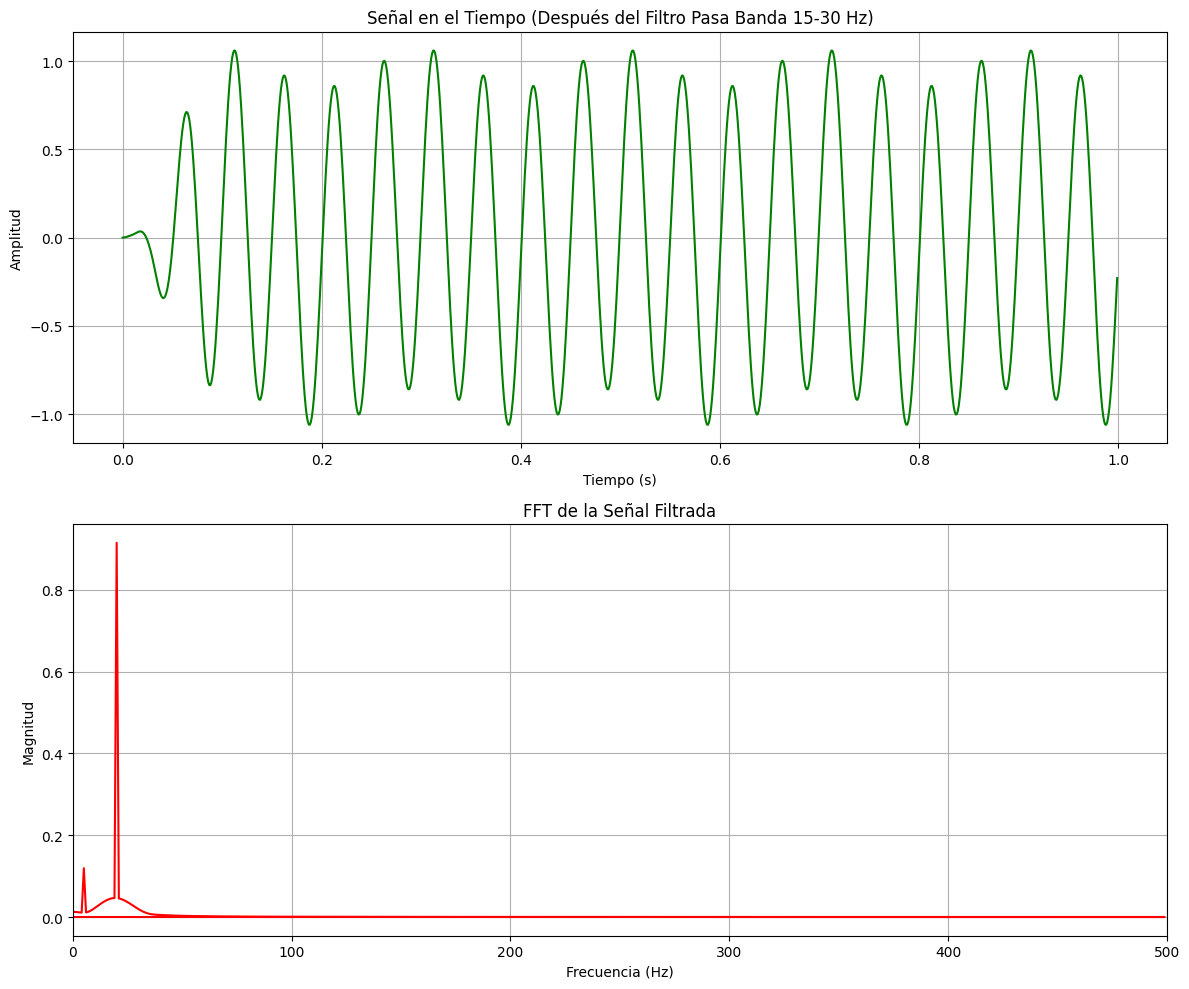

In [6]:
# Aplicar el filtro
fir = firwin(N, [f1, f2], pass_zero=False, fs=fs)
filtered_signal = lfilter(fir, 1.0, composite_signal)

# Ploteo
plt.figure(figsize=(12, 10))
plt.subplot(2, 1, 1)
plt.plot(t, filtered_signal, color='green')
plt.title('Señal en el Tiempo (Después del Filtro Pasa Banda 15-30 Hz)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)

#  FFT
N_fft_filt = len(filtered_signal)
yf_filt = np.fft.fft(filtered_signal)
xf_filt = np.fft.fftfreq(N_fft_filt, 1/fs)

plt.subplot(2, 1, 2)
plt.plot(xf_filt, 2/N_fft_filt * np.abs(yf_filt), color='red')
plt.title('FFT de la Señal Filtrada')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Magnitud')
plt.xlim(0, 500)
plt.grid(True)

plt.tight_layout()
plt.show()

## Ejercicio 2: Procesamiento de Señal ECG Sintética

Genere:
* ECG sintetico
* Ruido Blanco
* Interferencia de alta frecuencia

Diseñar filtros Lowpass y Bandpass

In [7]:
!pip install neurokit2

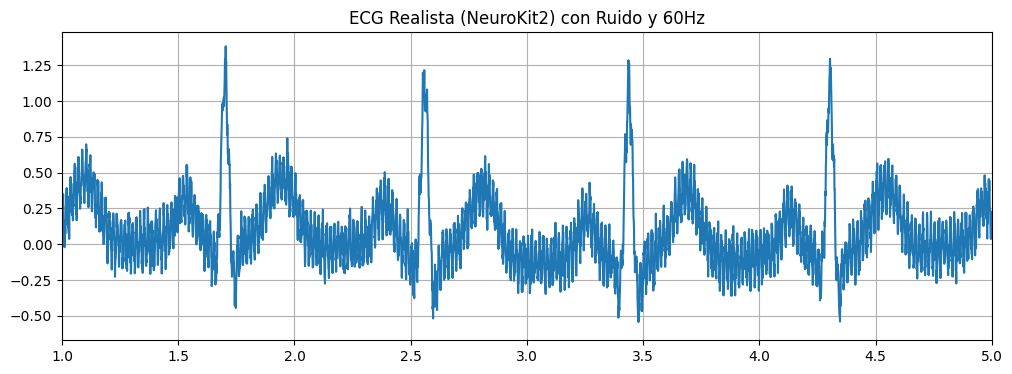

In [8]:
import neurokit2 as nk

fs_ecg = 1000
duration = 10
ecg_clean = nk.ecg_simulate(duration=duration, sampling_rate=fs_ecg, heart_rate=70)
t_ecg = np.linspace(0, duration, len(ecg_clean))

# Ruido Blanco
white_noise = 0.05 * np.random.normal(size=len(ecg_clean))

# Interferencia de alta frecuencia (60 Hz)
hf_noise = 0.15 * np.sin(2 * np.pi * 60 * t_ecg)

# Señal final contaminada
noisy_ecg = ecg_clean + white_noise + hf_noise

# Visualización inicial
plt.figure(figsize=(12, 4))
plt.plot(t_ecg, noisy_ecg)
plt.title('ECG Realista (NeuroKit2) con Ruido y 60Hz')
plt.xlim(1, 5)
plt.grid(True)
plt.show()

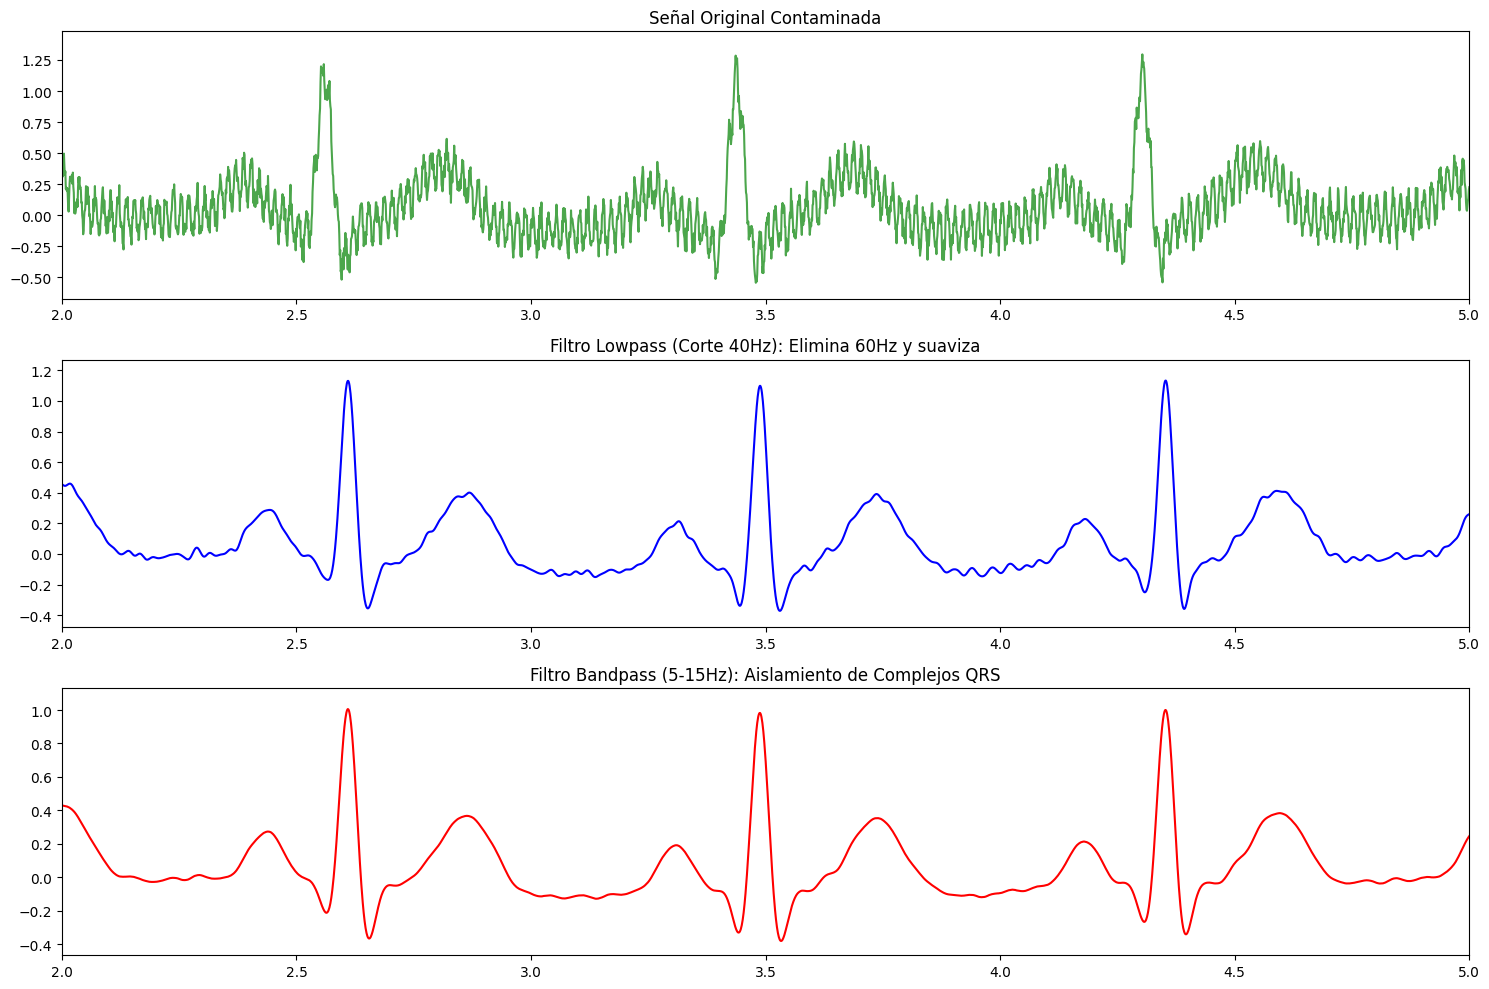

In [9]:
# Filtros
# Lowpass: Elimina ruido de alta frecuencia (>40Hz)
b_lp = firwin(101, 40, fs=fs_ecg)
ecg_filtered_lp = lfilter(b_lp, 1.0, noisy_ecg)

# Bandpass: Resalta QRS (frecuencias entre 5 y 15 Hz)
b_bp = firwin(101, [5, 15], pass_zero=False, fs=fs_ecg)
ecg_filtered_bp = lfilter(b_bp, 1.0, noisy_ecg)

# Ploteo
plt.figure(figsize=(15, 10))
plt.subplot(3, 1, 1)
plt.plot(t_ecg, noisy_ecg, color='green', alpha=0.7)
plt.title('Señal Original Contaminada')
plt.xlim(2, 5)

plt.subplot(3, 1, 2)
plt.plot(t_ecg, ecg_filtered_lp, color='blue')
plt.title('Filtro Lowpass (Corte 40Hz): Elimina 60Hz y suaviza')
plt.xlim(2, 5)

plt.subplot(3, 1, 3)
plt.plot(t_ecg, ecg_filtered_bp, color='red')
plt.title('Filtro Bandpass (5-15Hz): Aislamiento de Complejos QRS')
plt.xlim(2, 5)

plt.tight_layout()
plt.show()

## Ejercicio 3: Comparativa FIR Lowpass vs Filtro de Mediana (Señal EEG)

Evaluaremos el impacto de los filtros en una señal **EEG** contaminada con ruidos impulsivos aleatorios.

RMSE comparison
Signal with spikes : 0.2815
FIR lowpass filter : 0.1520
Median filter      : 0.0642


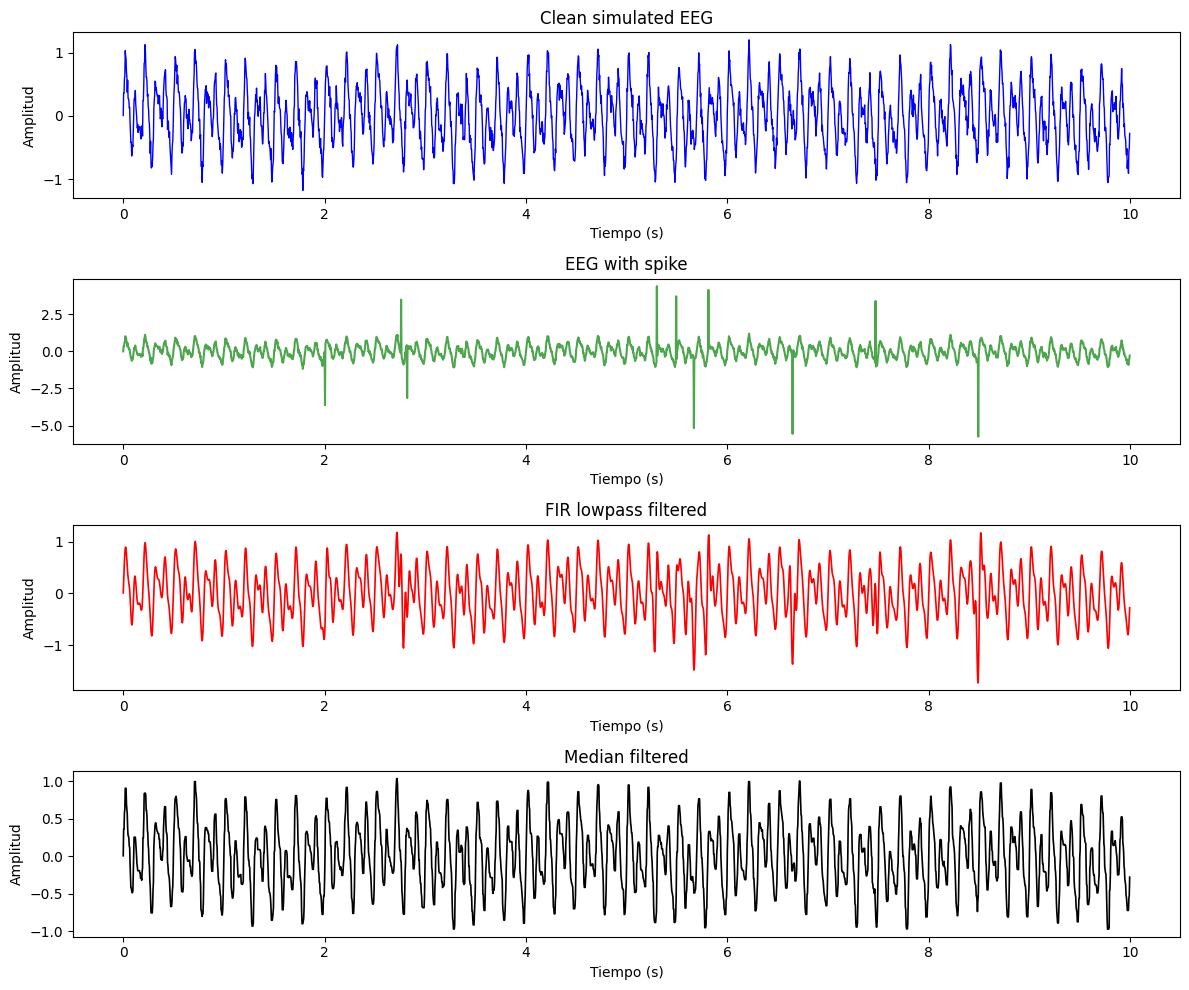

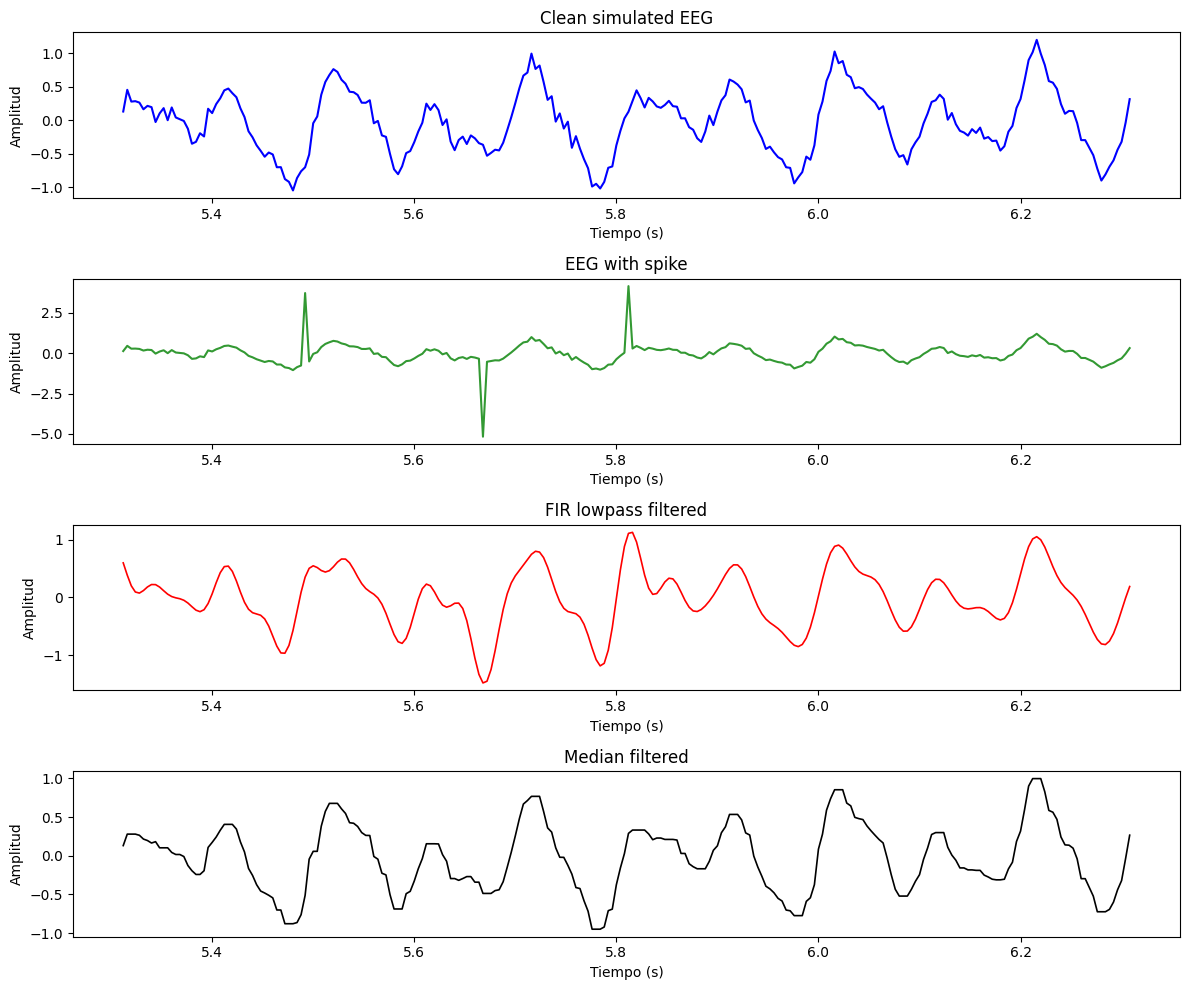

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import firwin, filtfilt, medfilt

fs = 250
duration = 10
t = np.arange(0, duration, 1/fs)
N = len(t)

np.random.seed(8)

theta = 0.35 * np.sin(2 * np.pi * 6 * t)      # Theta rhythm
alpha = 0.50 * np.sin(2 * np.pi * 10 * t)     # Alpha rhythm
beta  = 0.20 * np.sin(2 * np.pi * 20 * t)     # Beta rhythm

baseline_drift = 0.10 * np.sin(2 * np.pi * 0.5 * t)
gaussian_noise = 0.08 * np.random.randn(N)

eeg_clean = theta + alpha + beta + baseline_drift + gaussian_noise

eeg_spikes = eeg_clean.copy()

num_spikes = 10
spike_positions = np.random.choice(np.arange(100, N-100), num_spikes, replace=False)
spike_amplitudes = np.random.choice([-1, 1], num_spikes) * np.random.uniform(3, 6, num_spikes)

for pos, amp in zip(spike_positions, spike_amplitudes):
    eeg_spikes[pos] += amp

fir_order = 101
cutoff_freq = 30

fir_coeff = firwin(
    fir_order,
    cutoff_freq,
    pass_zero=True,
    fs=fs
)

eeg_fir = filtfilt(fir_coeff, 1.0, eeg_spikes)

kernel_size = 5
eeg_median = medfilt(eeg_spikes, kernel_size=kernel_size)

rmse_noisy = np.sqrt(np.mean((eeg_spikes - eeg_clean) ** 2))
rmse_fir = np.sqrt(np.mean((eeg_fir - eeg_clean) ** 2))
rmse_median = np.sqrt(np.mean((eeg_median - eeg_clean) ** 2))

print("RMSE comparison")
print(f"Signal with spikes : {rmse_noisy:.4f}")
print(f"FIR lowpass filter : {rmse_fir:.4f}")
print(f"Median filter      : {rmse_median:.4f}")

plt.figure(figsize=(12, 10))

plt.subplot(4, 1, 1)
plt.plot(t, eeg_clean, linewidth=1, color='blue')
plt.title("Clean simulated EEG")
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')

plt.subplot(4, 1, 2)
plt.plot(t, eeg_spikes, alpha=0.7, color='green')
plt.title("EEG with spike")
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')

plt.subplot(4, 1, 3)
plt.plot(t, eeg_fir, linewidth=1.2, color='red')
plt.title("FIR lowpass filtered")
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')

plt.subplot(4, 1, 4)
plt.plot(t, eeg_median, linewidth=1.2, color='black')
plt.title("Median filtered")
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')

plt.tight_layout()
plt.show()

# Zoom
selected_spike = spike_positions[0]
zoom_samples = int(0.5 * fs)

start = max(selected_spike - zoom_samples, 0)
end = min(selected_spike + zoom_samples, N)

plt.figure(figsize=(12, 10))

plt.subplot(4, 1, 1)
plt.plot(t[start:end], eeg_clean[start:end], linewidth=1.5, color='blue')
plt.title("Clean simulated EEG")
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')

plt.subplot(4, 1, 2)
plt.plot(t[start:end], eeg_spikes[start:end], alpha=0.8, color='green')
plt.title("EEG with spike")
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')

plt.subplot(4, 1, 3)
plt.plot(t[start:end], eeg_fir[start:end], linewidth=1.2, color='red')
plt.title("FIR lowpass filtered")
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')

plt.subplot(4, 1, 4)
plt.plot(t[start:end], eeg_median[start:end], linewidth=1.2, color='black')
plt.title("Median filtered")
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')

plt.tight_layout()
plt.show()


El filtro de mediana ofrece un mejor rendimiento con ruido impulsivo, ya que elimina los picos aislados y abruptos sin distorsionar significativamente la forma de onda EEG circundante.

El filtro paso bajo FIR atenúa los componentes de alta frecuencia, pero los picos impulsivos afectan un amplio rango de frecuencias, por lo que el artefacto de pico se suaviza en lugar de eliminarse por completo.


## Ejercicio 4: Interferencia Eléctrica de 60 Hz

Simule:
* ECG
* Ruido de 60 Hz
* Ruido blanco

Diseñe un pipeline que elimine:
* Interferencia eléctrica
* Ruido de alta frecuencia



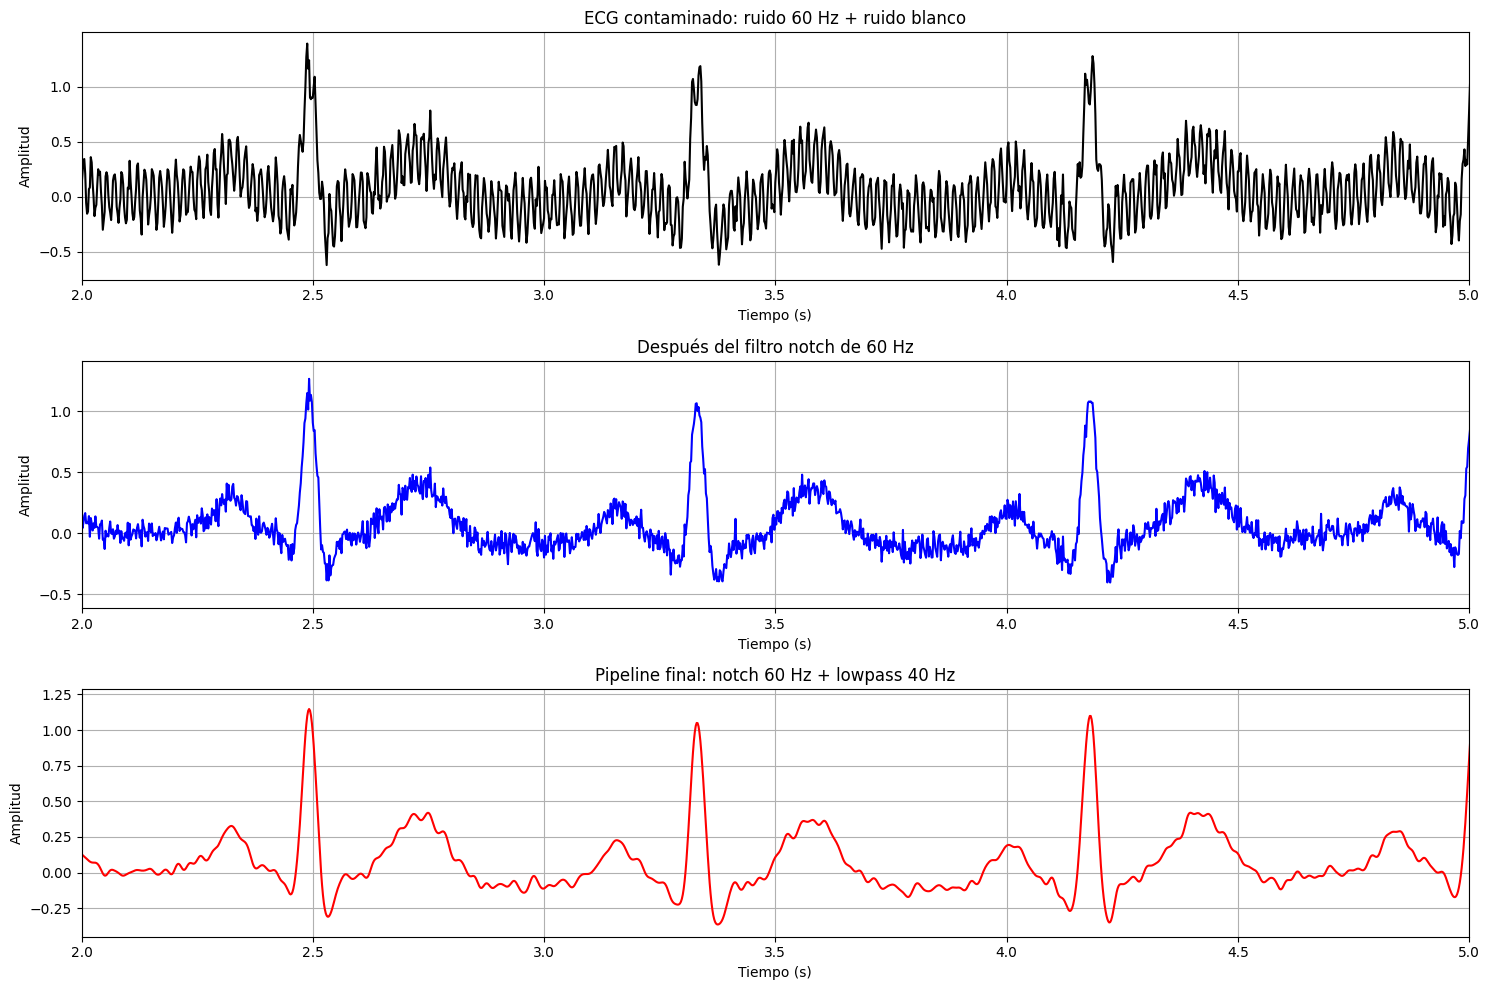

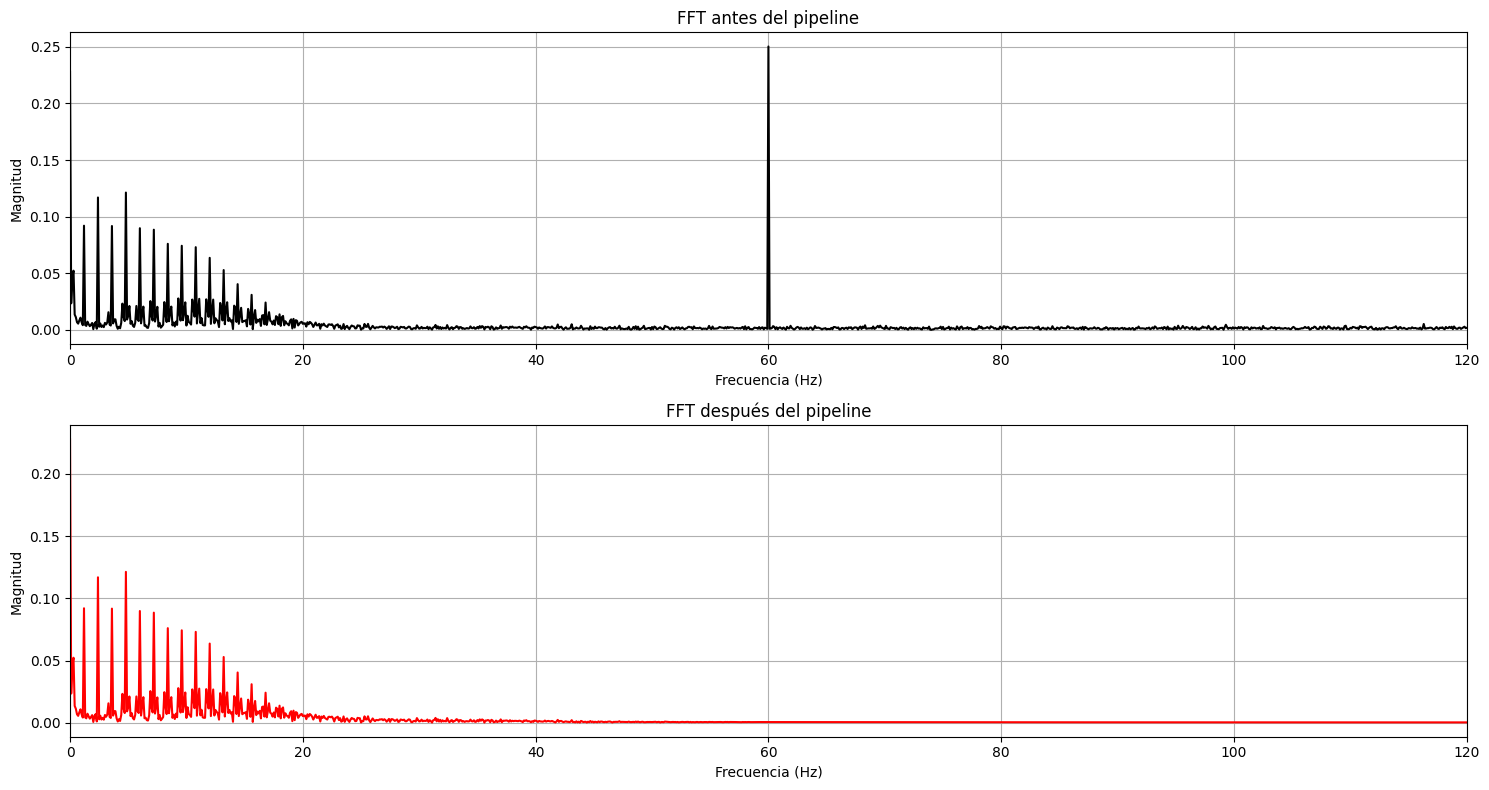

In [20]:
from scipy.signal import iirnotch, butter, filtfilt

# Parámetros de señal
fs_ecg = 500
duration = 10
t_ecg = np.linspace(0, duration, int(fs_ecg * duration), endpoint=False)

# ECG sintético
ecg_clean = nk.ecg_simulate(duration=duration, sampling_rate=fs_ecg, heart_rate=72)

# Interferencia eléctrica de 60 Hz y ruido blanco
powerline_noise = 0.25 * np.sin(2 * np.pi * 60 * t_ecg)
white_noise = 0.06 * np.random.normal(size=len(t_ecg))

# Señal ECG contaminada
ecg_noisy = ecg_clean + powerline_noise + white_noise

# 1) Filtro notch para eliminar la interferencia de 60 Hz
b_notch, a_notch = iirnotch(w0=60, Q=30, fs=fs_ecg)
ecg_notch = filtfilt(b_notch, a_notch, ecg_noisy)

# 2) Filtro lowpass para eliminar ruido de alta frecuencia
# En ECG, un corte cercano a 40 Hz permite conservar la morfología principal.
b_lp, a_lp = butter(N=4, Wn=40, btype='low', fs=fs_ecg)
ecg_pipeline = filtfilt(b_lp, a_lp, ecg_notch)

# Función auxiliar para FFT
def plot_fft(signal, fs, title, color=None):
    N_fft = len(signal)
    freqs = np.fft.rfftfreq(N_fft, d=1/fs)
    spectrum = 2/N_fft * np.abs(np.fft.rfft(signal))
    plt.plot(freqs, spectrum, color=color)
    plt.title(title)
    plt.xlabel('Frecuencia (Hz)')
    plt.ylabel('Magnitud')
    plt.xlim(0, 120)
    plt.grid(True)

# Visualización temporal
plt.figure(figsize=(15, 10))

plt.subplot(3, 1, 1)
plt.plot(t_ecg, ecg_noisy, color='black')
plt.title('ECG contaminado: ruido 60 Hz + ruido blanco')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.xlim(2, 5)
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(t_ecg, ecg_notch, color='blue')
plt.title('Después del filtro notch de 60 Hz')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.xlim(2, 5)
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(t_ecg, ecg_pipeline, color='red')
plt.title('Pipeline final: notch 60 Hz + lowpass 40 Hz')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.xlim(2, 5)
plt.grid(True)

plt.tight_layout()
plt.show()

# Visualización en frecuencia
plt.figure(figsize=(15, 8))

plt.subplot(2, 1, 1)
plot_fft(ecg_noisy, fs_ecg, 'FFT antes del pipeline', color='black')

plt.subplot(2, 1, 2)
plot_fft(ecg_pipeline, fs_ecg, 'FFT después del pipeline', color='red')

plt.tight_layout()
plt.show()


**Interpretación:** el filtro notch atenúa específicamente la componente de 60 Hz producida por la red eléctrica. Luego, el filtro lowpass reduce el ruido de alta frecuencia sin eliminar la morfología principal del ECG. Por eso, el pipeline más adecuado es: **notch 60 Hz → lowpass 40 Hz**.


## Ejercicio 5: Sensores Desincronizados

Genere:
* ECG
* Respiración
* Acelerómetro

Cada señal debe tener un delay distinto en múltiplos de 2 s y ruido gaussiano. Luego, sincronice todas usando correlación cruzada.

En este ejercicio se toma el **ECG como referencia temporal**. La respiración se retrasa 2 s y el acelerómetro 4 s.


Para que la correlación cruzada sea aplicable entre sensores de distinta naturaleza, se incorpora una componente común de eventos fisiológicos/movimiento en las tres señales.

Delay estimado Respiración vs ECG: 200 muestras = 2.00 s
Delay estimado Acelerómetro vs ECG: 398 muestras = 3.98 s


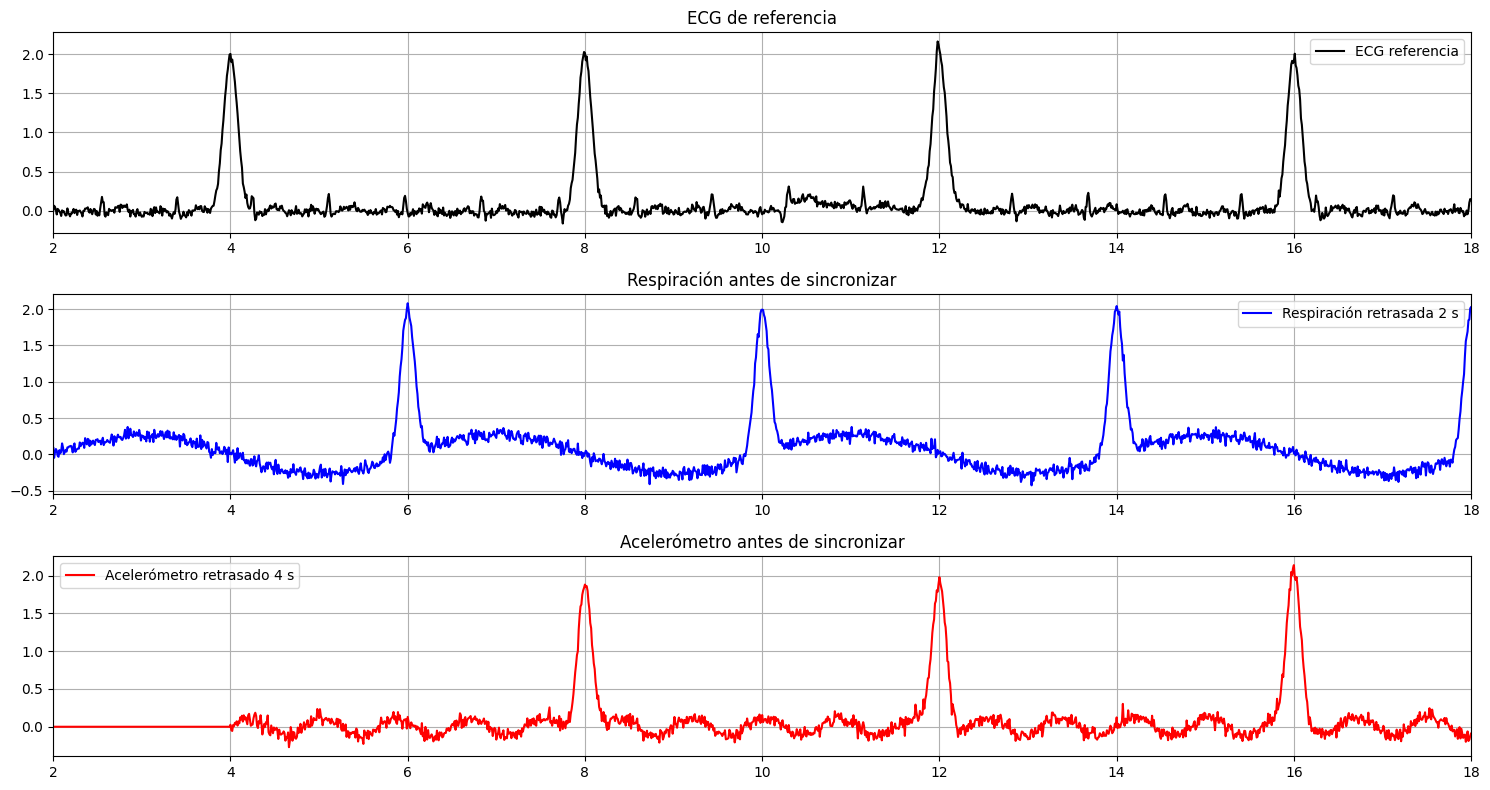

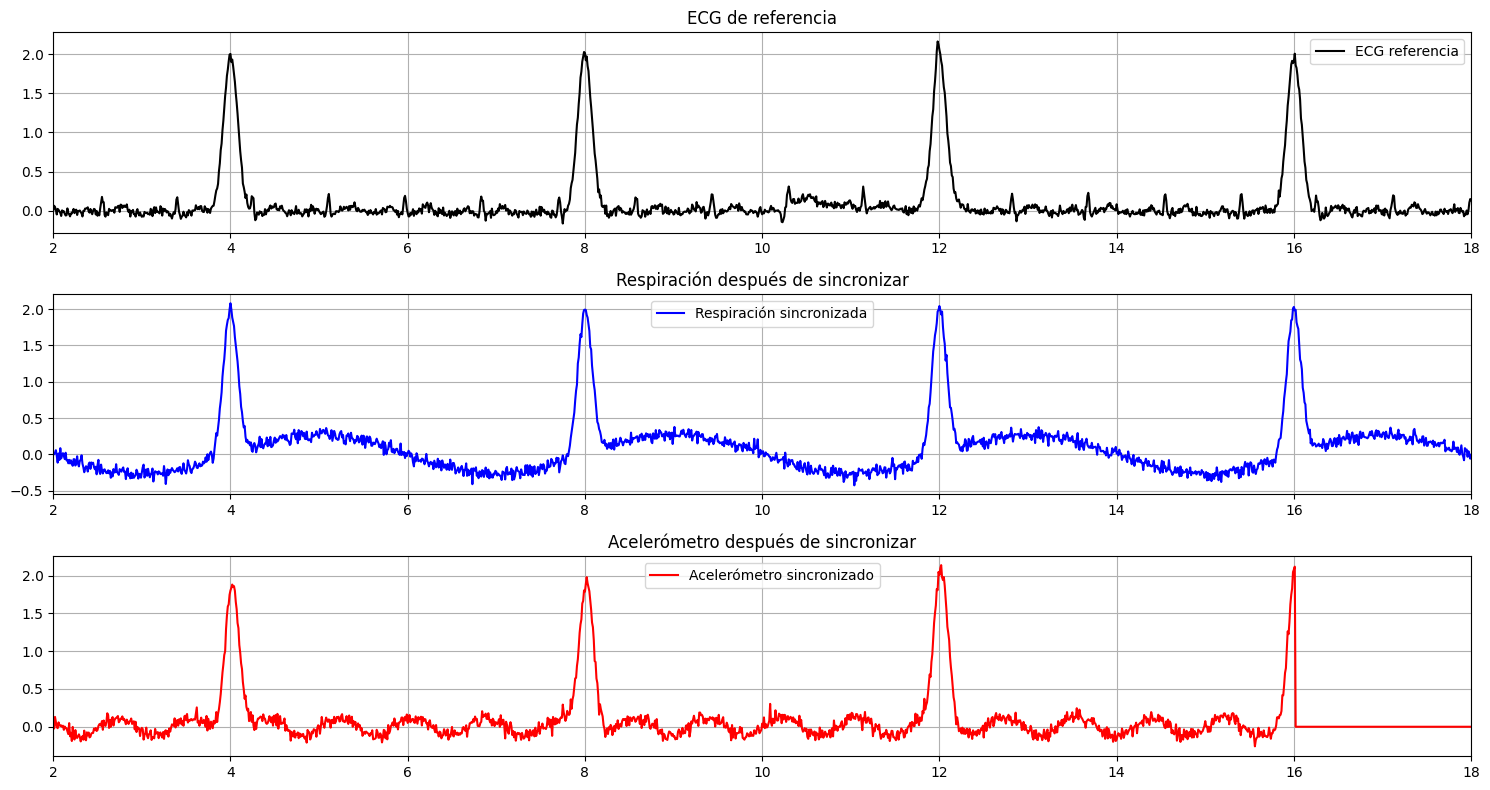

In [21]:
from scipy.signal import correlate, correlation_lags

# Parámetros generales
fs_sync = 100
duration = 20
t_sync = np.linspace(0, duration, int(fs_sync * duration), endpoint=False)

# Función auxiliar: pulsos gaussianos que representan eventos comunes observados por los sensores
def gaussian_events(t, event_times, width=0.08):
    events = np.zeros_like(t)
    for ev in event_times:
        events += np.exp(-0.5 * ((t - ev) / width) ** 2)
    return events

# Función auxiliar: aplicar delay con relleno de ceros, evitando el wrap-around de np.roll
def apply_delay(signal, delay_samples):
    delayed = np.zeros_like(signal)
    if delay_samples > 0:
        delayed[delay_samples:] = signal[:-delay_samples]
    elif delay_samples < 0:
        delayed[:delay_samples] = signal[-delay_samples:]
    else:
        delayed = signal.copy()
    return delayed

# Función auxiliar: estimar delay por correlación cruzada
def estimate_delay(reference, signal, fs):
    ref_z = (reference - np.mean(reference)) / np.std(reference)
    sig_z = (signal - np.mean(signal)) / np.std(signal)
    corr = correlate(sig_z, ref_z, mode='full')
    lags = correlation_lags(len(sig_z), len(ref_z), mode='full')
    estimated_delay_samples = lags[np.argmax(corr)]
    estimated_delay_seconds = estimated_delay_samples / fs
    return estimated_delay_samples, estimated_delay_seconds, corr, lags

# Componente común para facilitar la sincronización por correlación cruzada
event_times = [4, 8, 12, 16]
sync_component = gaussian_events(t_sync, event_times, width=0.08)

# Señales biomédicas simuladas
ecg_base = nk.ecg_simulate(duration=duration, sampling_rate=fs_sync, heart_rate=70)
resp_base = 0.9 * np.sin(2 * np.pi * 0.25 * t_sync)
acc_base = 0.4 * np.sin(2 * np.pi * 1.2 * t_sync)

# Se agrega una componente común dominante a los sensores y ruido gaussiano.
# Esto hace que la correlación cruzada tenga una referencia temporal clara.
ecg_signal = 0.25 * ecg_base + 2.0 * sync_component + 0.03 * np.random.normal(size=len(t_sync))
resp_signal = 0.30 * resp_base + 2.0 * sync_component + 0.05 * np.random.normal(size=len(t_sync))
acc_signal = 0.30 * acc_base + 2.0 * sync_component + 0.05 * np.random.normal(size=len(t_sync))

# Delays distintos: ECG = 0 s, Respiración = 2 s, Acelerómetro = 4 s
delay_ecg_samples = int(0 * fs_sync)
delay_resp_samples = int(2 * fs_sync)
delay_acc_samples = int(4 * fs_sync)

ecg_delayed = apply_delay(ecg_signal, delay_ecg_samples)
resp_delayed = apply_delay(resp_signal, delay_resp_samples)
acc_delayed = apply_delay(acc_signal, delay_acc_samples)

# Estimación de delays respecto al ECG
delay_resp_est, delay_resp_sec, _, _ = estimate_delay(ecg_delayed, resp_delayed, fs_sync)
delay_acc_est, delay_acc_sec, _, _ = estimate_delay(ecg_delayed, acc_delayed, fs_sync)

print(f"Delay estimado Respiración vs ECG: {delay_resp_est} muestras = {delay_resp_sec:.2f} s")
print(f"Delay estimado Acelerómetro vs ECG: {delay_acc_est} muestras = {delay_acc_sec:.2f} s")

# Corrección: si una señal está retrasada, se desplaza hacia la izquierda
resp_aligned = apply_delay(resp_delayed, -delay_resp_est)
acc_aligned = apply_delay(acc_delayed, -delay_acc_est)

# Visualización antes de sincronizar
plt.figure(figsize=(15, 8))

plt.subplot(3, 1, 1)
plt.plot(t_sync, ecg_delayed, label='ECG referencia', color='black')
plt.title('ECG de referencia')
plt.xlim(2, 18)
plt.grid(True)
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(t_sync, resp_delayed, label='Respiración retrasada 2 s', color='blue')
plt.title('Respiración antes de sincronizar')
plt.xlim(2, 18)
plt.grid(True)
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(t_sync, acc_delayed, label='Acelerómetro retrasado 4 s', color='red')
plt.title('Acelerómetro antes de sincronizar')
plt.xlim(2, 18)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# Visualización después de sincronizar
plt.figure(figsize=(15, 8))

plt.subplot(3, 1, 1)
plt.plot(t_sync, ecg_delayed, label='ECG referencia', color='black')
plt.title('ECG de referencia')
plt.xlim(2, 18)
plt.grid(True)
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(t_sync, resp_aligned, label='Respiración sincronizada', color='blue')
plt.title('Respiración después de sincronizar')
plt.xlim(2, 18)
plt.grid(True)
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(t_sync, acc_aligned, label='Acelerómetro sincronizado', color='red')
plt.title('Acelerómetro después de sincronizar')
plt.xlim(2, 18)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


La correlación cruzada estima cuántas muestras se debe desplazar una señal para alinearla con la referencia. En este caso, la respiración debe corregirse aproximadamente 2 s y el acelerómetro aproximadamente 4 s. Después de aplicar el desplazamiento inverso, los eventos comunes quedan temporalmente alineados.


## Ejercicio 6: Resampling Multisensor

Simule:
* ECG a 500 Hz
* Respiración a 100 Hz
* Acelerómetro a 200 Hz

Lleve todas las señales a 500 Hz y sincronícelas temporalmente.

Delay estimado Respiración remuestreada vs ECG: 502 muestras = 1.00 s
Delay estimado Acelerómetro remuestreado vs ECG: 248 muestras = 0.50 s


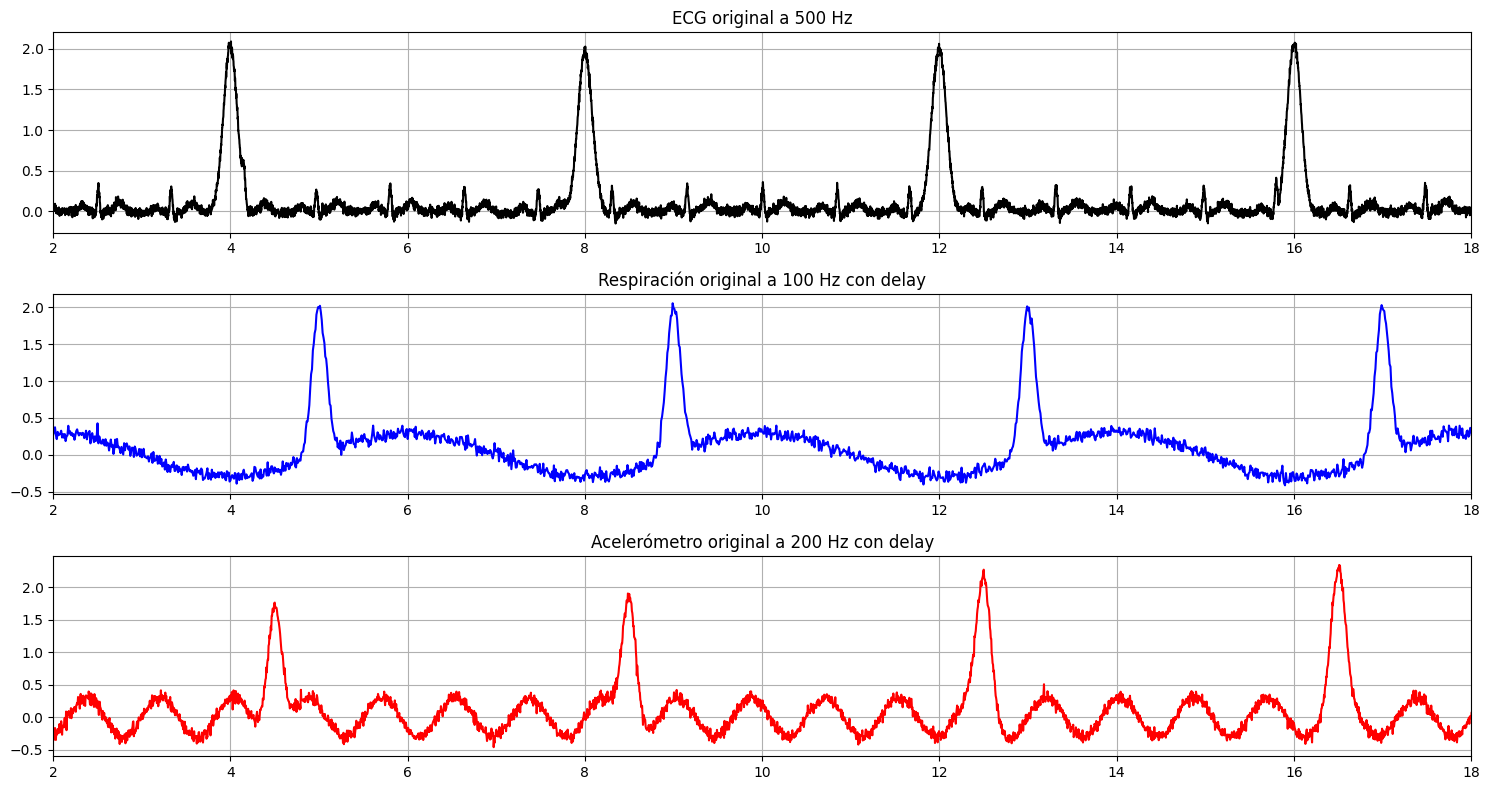

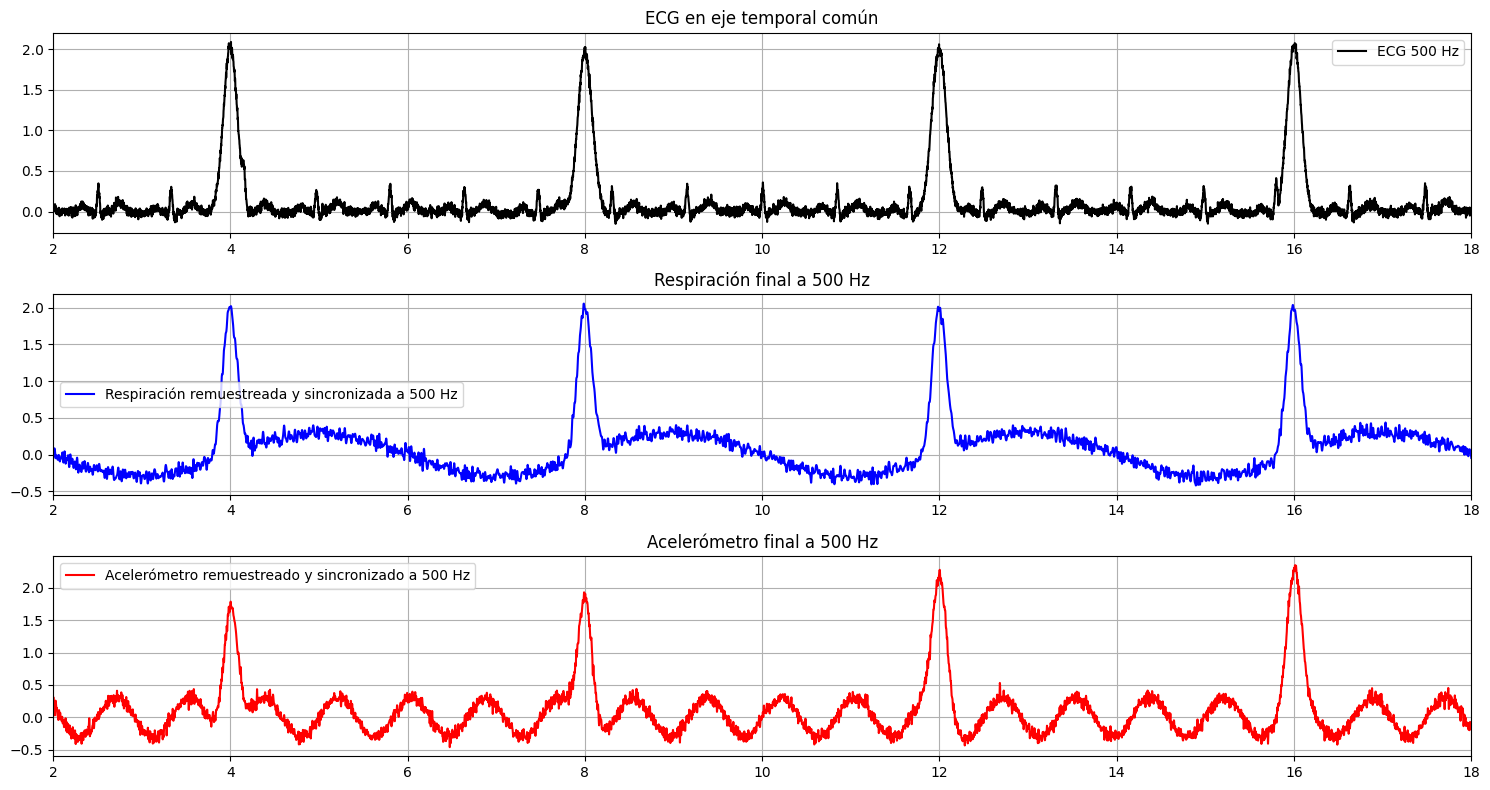

In [22]:
from scipy.signal import resample

# Frecuencias de muestreo
fs_ecg = 500
fs_resp = 100
fs_acc = 200
fs_target = 500
duration = 20

# Vectores temporales originales
t_ecg = np.linspace(0, duration, int(fs_ecg * duration), endpoint=False)
t_resp = np.linspace(0, duration, int(fs_resp * duration), endpoint=False)
t_acc = np.linspace(0, duration, int(fs_acc * duration), endpoint=False)

# Eventos comunes en cada frecuencia de muestreo
event_times = [4, 8, 12, 16]
sync_ecg = gaussian_events(t_ecg, event_times, width=0.08)
sync_resp = gaussian_events(t_resp, event_times, width=0.08)
sync_acc = gaussian_events(t_acc, event_times, width=0.08)

# Señales simuladas con distintas frecuencias de muestreo
ecg_500_base = nk.ecg_simulate(duration=duration, sampling_rate=fs_ecg, heart_rate=72)
ecg_500 = 0.25 * ecg_500_base + 2.0 * sync_ecg + 0.03 * np.random.normal(size=len(t_ecg))

resp_100 = 0.30 * np.sin(2 * np.pi * 0.25 * t_resp) + 2.0 * sync_resp
resp_100 = resp_100 + 0.05 * np.random.normal(size=len(t_resp))

acc_200 = 0.30 * np.sin(2 * np.pi * 1.2 * t_acc) + 2.0 * sync_acc
acc_200 = acc_200 + 0.05 * np.random.normal(size=len(t_acc))

# Se agregan delays antes del remuestreo para simular sensores que inician en tiempos distintos
resp_delay_samples = int(1.0 * fs_resp)   # 1 s
acc_delay_samples = int(0.5 * fs_acc)     # 0.5 s

resp_100_delayed = apply_delay(resp_100, resp_delay_samples)
acc_200_delayed = apply_delay(acc_200, acc_delay_samples)

# Resampling a 500 Hz
resp_500 = resample(resp_100_delayed, len(ecg_500))
acc_500 = resample(acc_200_delayed, len(ecg_500))

# Vector temporal común a 500 Hz
t_common = t_ecg

# Estimación de delays luego del resampling, usando ECG como referencia
delay_resp_est, delay_resp_sec, _, _ = estimate_delay(ecg_500, resp_500, fs_target)
delay_acc_est, delay_acc_sec, _, _ = estimate_delay(ecg_500, acc_500, fs_target)

print(f"Delay estimado Respiración remuestreada vs ECG: {delay_resp_est} muestras = {delay_resp_sec:.2f} s")
print(f"Delay estimado Acelerómetro remuestreado vs ECG: {delay_acc_est} muestras = {delay_acc_sec:.2f} s")

# Alineamiento temporal
resp_500_aligned = apply_delay(resp_500, -delay_resp_est)
acc_500_aligned = apply_delay(acc_500, -delay_acc_est)

# Visualización de las señales originales con frecuencias distintas
plt.figure(figsize=(15, 8))

plt.subplot(3, 1, 1)
plt.plot(t_ecg, ecg_500, color='black')
plt.title('ECG original a 500 Hz')
plt.xlim(2, 18)
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(t_resp, resp_100_delayed, color='blue')
plt.title('Respiración original a 100 Hz con delay')
plt.xlim(2, 18)
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(t_acc, acc_200_delayed, color='red')
plt.title('Acelerómetro original a 200 Hz con delay')
plt.xlim(2, 18)
plt.grid(True)

plt.tight_layout()
plt.show()

# Visualización luego de resampling y sincronización
plt.figure(figsize=(15, 8))

plt.subplot(3, 1, 1)
plt.plot(t_common, ecg_500, label='ECG 500 Hz', color='black')
plt.title('ECG en eje temporal común')
plt.xlim(2, 18)
plt.grid(True)
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(t_common, resp_500_aligned, label='Respiración remuestreada y sincronizada a 500 Hz', color='blue')
plt.title('Respiración final a 500 Hz')
plt.xlim(2, 18)
plt.grid(True)
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(t_common, acc_500_aligned, label='Acelerómetro remuestreado y sincronizado a 500 Hz', color='red')
plt.title('Acelerómetro final a 500 Hz')
plt.xlim(2, 18)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


Primero se remuestrean las señales de respiración y acelerómetro para que tengan el mismo número de muestras que el ECG a 500 Hz. Luego, con correlación cruzada se estima el desfase temporal respecto al ECG y se corrige desplazando cada señal en sentido contrario. Así, las tres señales quedan en el mismo eje temporal y con la misma frecuencia de muestreo.